In [1]:
import numpy as np

import pandas as pd
import copy
import math
from collections import OrderedDict, Counter
#from multiprocessing import Pool
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
#from scipy.integrate import odeint
from scipy.integrate import solve_ivp
import sympy as sp
from scipy.optimize import fsolve

In [2]:
_Data_PATH_XX_ = './simulation_results/phase diagram/'
_Figure_PATH_XX_ = './figures/'

In [3]:
N = 2000
mu = 1          #恢复速率
beta = 0.6      #传播速率与接触人数的乘积
alpha = 0.5     #防护效果
w = 1         #行为更新速率 （如果结果不稳定，可能是由于更新过快的原因）
c0 = 1          #采取防护措施的花费
cI = 6          #被感染后的代价
ita =0.001          #社会一致性的影响强度
k = 10           #每时间步平均接触人数或者网络度
gamma = 1       #由于媒体宣传，夸大感染能力或者对感染能力的误判

Init_condition_list = [[0.01, 0.05]]

n_inf = Init_condition_list[0][0]
n_take = Init_condition_list[0][1]

t_span=[0,1000]
t_eval = np.linspace(t_span[0], t_span[1], 1000000)
beta_list = [0.01 * i for i in range(101)]
cI_list = [1 + 0.1*i for i in range(101)]
alpha_list = [0.01*i for i in range(101)]
gamma_list = [0.5+0.03*i for i in range(101)]
ita_list = [0.004*i for i in range(101)]

phase = ['alpha-beta','cI-beta','gamma-beta','ita-beta']
phase_index = 1  #决定跑哪个相图数据

In [4]:
def f(x):
    return (1-x)*(2*ita + c0) / (x * math.exp(math.log(1-x)/x)) - cI

def precaution_occur(alpha_y, cI_y, gamma_y):
    
    x = sp.symbols('x')
    equation = sp.Eq(sp.exp(-(1-alpha_y)*x)-sp.exp(-x)-(2*ita+c0)/cI_y, 0)
    
    solutions = sp.solve(equation, x)
    
    thre = set()
    for z in solutions:
        thre.add((z/gamma_y+mu)/k)
    
    #print([alpha_y,cI_y,gamma_y])
    
    return list(thre)

def thres_x(x, alpha_y, cI_y):
    return np.exp(-(1-alpha_y)*x)-np.exp(-x)-(2*ita+c0)/cI_y
def numerical_x(alpha_y, cI_y):
    x0_list = [0.1,3.8]
    x_num = [fsolve(thres_x, x0, args=(alpha_y, cI_y))[0] for x0 in x0_list]
    thre = set()
    for z in x_num:
        thre.add((z/gamma+mu)/k)
    
    print([alpha_y,cI_y])
    return list(thre)

if phase_index == 1:
    beta_low = []
    beta_high = []
    cI_thres = (1-alpha)*(2*ita + c0) / (alpha * math.exp(math.log(1-alpha)/alpha))
    cI_c = [cI_thres+0.1*(i+1) for i in range(50)]
    cI_clip =[]
    for cI_value in cI_c:
        cI_clip.append((cI_value-1)*10)
        res_beta = precaution_occur(alpha, cI_value,gamma)
        beta_low.append(min(res_beta)*100)
        beta_high.append(max(res_beta)*100)
    
if phase_index == 0:
    alpha_thres = fsolve(f, x0=0.1)
    #print(type(alpha_thres[0]))
    beta_low = []
    beta_high = []
    alpha_c = [alpha_thres[0] + 0.02* (i+1) for i in range(30)]
    alpha_clip =[]
    for alpha_value in alpha_c:
        alpha_clip.append(alpha_value*100)
        res_beta = numerical_x(alpha_value, cI)
        #res_beta = precaution_occur(0.42, cI)
        beta_low.append(min(res_beta)*100)
        beta_high.append(max(res_beta)*100)

if phase_index == 2:
    beta_low = []
    beta_high = []
    gamma_clip = []
    for gamma_value in gamma_list:
        gamma_clip.append((gamma_value-0.5)*100/3)
        res_beta = precaution_occur(alpha, cI,gamma_value)
        beta_low.append(min(res_beta)*100)
        beta_high.append(max(res_beta)*100)
    
    print(beta_high)

In [5]:
if phase_index == 0:
    #alpha-beta-phase-diagram
    filename1 = 'alpha-beta-Phasediagram-inf_N'+str(N)+'k' + str(k) + '_mu'+ str(mu) +  '_w' + str(w) + '_cI' +str(cI) +'_ita'+str(ita)+'gamma'+str(gamma)+'n_inf'+str(n_inf)+'n_take'+str(n_take)
    filename2 = 'alpha-beta-Phasediagram-take_N'+str(N)+'k' + str(k) + '_mu'+ str(mu)  + '_w' + str(w) + '_cI' +str(cI) +'_ita'+str(ita)+'gamma'+str(gamma)+'n_inf'+str(n_inf)+'n_take'+str(n_take)
        
if phase_index == 1:
    #CI-beta
    filename1 = 'cI-beta-Phasediagram-inf_N'+str(N)+'k' + str(k) + '_mu'+ str(mu) + '_alpha' + str(alpha) + '_w' + str(w) + '_ita'+str(ita)+'gamma'+str(gamma)+'n_inf'+str(n_inf)+'n_take'+str(n_take)
    filename2 = 'cI-beta-Phasediagram-take_N'+str(N)+'k' + str(k) + '_mu'+ str(mu) + '_alpha' + str(alpha) + '_w' + str(w) + '_ita'+str(ita)+'gamma'+str(gamma)+'n_inf'+str(n_inf)+'n_take'+str(n_take)

if phase_index == 2:
    #gamma-beta
    filename1 = 'gamma-beta-Phasediagram-inf_N'+str(N)+'k' + str(k) + '_mu'+ str(mu) + '_alpha' + str(alpha) + '_w' + str(w) + '_cI' +str(cI) +'_ita'+str(ita)+'n_inf'+str(n_inf)+'n_take'+str(n_take)
    filename2 = 'gamma-beta-Phasediagram-take_N'+str(N)+'k' + str(k) + '_mu'+ str(mu) + '_alpha' + str(alpha) + '_w' + str(w) + '_cI' +str(cI) +'_ita'+str(ita)+'n_inf'+str(n_inf)+'n_take'+str(n_take)

if phase_index == 3:
    #ita-beta
    filename1 = 'ita-beta-Phasediagram-inf_N'+str(N)+'k' + str(k) + '_mu'+ str(mu) + '_alpha' + str(alpha) + '_w' + str(w) + '_cI' +str(cI) +'gamma'+str(gamma)+'n_inf'+str(n_inf)+'n_take'+str(n_take)
    filename2 = 'ita-beta-Phasediagram-take_N'+str(N)+'k' + str(k) + '_mu'+ str(mu) + '_alpha' + str(alpha) + '_w' + str(w) + '_cI' +str(cI) +'gamma'+str(gamma)+'n_inf'+str(n_inf)+'n_take'+str(n_take)

In [6]:
phase_inf = np.loadtxt(_Data_PATH_XX_ + filename1 + '.txt')
phase_take = np.loadtxt(_Data_PATH_XX_ + filename2 + '.txt')

C:\Users\longzhao\AppData\Local\Temp\ipykernel_464\669126623.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  im = plt.pcolormesh(np.transpose(phase_inf),cmap=plt.cm.get_cmap('viridis'),shading='gouraud',vmin=0,vmax=1)


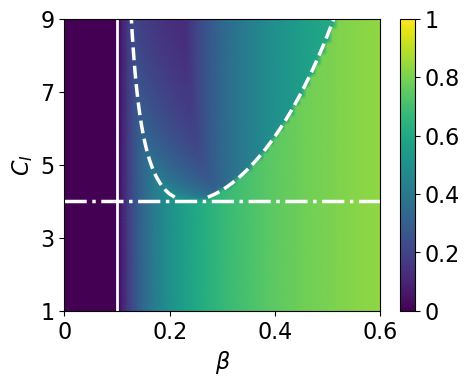

In [7]:
plt.figure(figsize=(5,4))
#color_map=['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b','w','r','green']
colormap=["#FFFFFF"]

#画图---相图
im = plt.pcolormesh(np.transpose(phase_inf),cmap=plt.cm.get_cmap('viridis'),shading='gouraud',vmin=0,vmax=1)
#im = plt.pcolormesh(np.transpose(phase_take),cmap=plt.cm.get_cmap('magma'),shading='gouraud',vmin=0,vmax=1)
#plt.plot(x_span_lam2,y_span_lamtri,color='w', linewidth = 3.5)
cb=plt.colorbar(im,)
cb.ax.tick_params(labelsize=16)
font = {'family' : 'Arial',
        'weight' : 'normal',
        'size'   : 16,
        }
#cb.set_label('Prevalence',fontdict=font)
cbar_ticks = np.linspace(0, 1, 6)
cb.set_ticks(cbar_ticks)
cb.set_ticklabels(('0','0.2','0.4','0.6','0.8','1'))

if phase_index == 1:
    plt.plot([0,80], [(cI_thres-1) * 10, (cI_thres-1)  * 10], '-.', color='white', linewidth=2.5)
    plt.plot(beta_low, cI_clip, '--', color='white', linewidth=2.5)
    plt.plot(beta_high, cI_clip, '--', color='white', linewidth=2.5)
    plt.plot([mu/k*100, mu/k*100], [0,100], '-', color='white', linewidth=2)
    
if phase_index == 0:
    plt.plot([0,80], [alpha_thres * 100, alpha_thres * 100], '-.', color='white', linewidth=2.5)
    plt.plot(beta_low, alpha_clip, '--', color='white', linewidth=2.5)
    plt.plot(beta_high, alpha_clip, '--', color='white', linewidth=2.5)
    plt.plot([mu/k*100, mu/k*100], [0,100], '-', color='white', linewidth=2)
    
#if phase_index == 2:
    #plt.plot(beta_low, gamma_clip, '--', color='white', linewidth=2.5)
    #plt.plot(beta_high, gamma_clip, '--', color='white', linewidth=2.5)

plt.xlim((0,60))
plt.ylim((0,80))
plt.xlabel('$\\beta$',fontsize=16)
plt.xticks(np.arange(0,61,20),['0','0.2','0.4','0.6'],fontsize=16)
#plt.xticks(np.arange(0,81,20),['0','0.2','0.4','0.6','0.8'],fontsize=16)
#plt.ylabel('$\\alpha$',fontsize=16)
#plt.yticks(np.arange(0,101,20),['0','0.2','0.4','0.6','0.8','1'],fontsize=16)
plt.ylabel('$C_I$',fontsize=16)
plt.yticks(np.arange(0,81,20),['1','3','5','7','9'],fontsize=16)
#plt.ylabel('$\\gamma$',fontsize=16)
#plt.yticks(np.arange(0,101,20),['0.5','1.1','1.7','2.3','2.9','3.5'],fontsize=16)
#plt.ylabel('$ita$',fontsize=16)
#plt.yticks(np.arange(0,101,20),['0','0.2','0.4','0.6','0.8','1'],fontsize=16)
plt.subplots_adjust(left=0.15,bottom=0.15,right=0.94)
plt.savefig(_Figure_PATH_XX_ + filename1 + '.png', dpi = 400)

C:\Users\longzhao\AppData\Local\Temp\ipykernel_464\3551337883.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  im = plt.pcolormesh(np.transpose(phase_take),cmap=plt.cm.get_cmap('magma'),shading='gouraud',vmin=0,vmax=1)


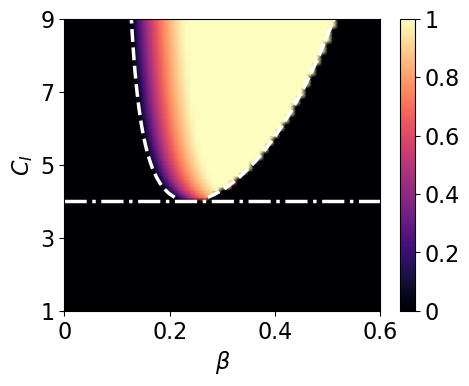

In [8]:
plt.figure(figsize=(5,4))
#color_map=['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b','w','r','green']
colormap=["#FFFFFF"]

#画图---相图
#im = plt.pcolormesh(np.transpose(phase),cmap=plt.cm.CMRmap,shading='gouraud',vmin=0,vmax=1)
im = plt.pcolormesh(np.transpose(phase_take),cmap=plt.cm.get_cmap('magma'),shading='gouraud',vmin=0,vmax=1)
#plt.plot(x_span_lam2,y_span_lamtri,color='w', linewidth = 3.5)
cb=plt.colorbar(im,)
cb.ax.tick_params(labelsize=16)
font = {'family' : 'Arial',
        'weight' : 'normal',
        'size'   : 16,
        }
#cb.set_label('Prevalence',fontdict=font)
cbar_ticks = np.linspace(0, 1, 6)
cb.set_ticks(cbar_ticks)
cb.set_ticklabels(('0','0.2','0.4','0.6','0.8','1'))

if phase_index == 1:
    plt.plot([0,80], [(cI_thres-1) * 10, (cI_thres-1)  * 10], '-.', color='white', linewidth=2.5)
    plt.plot(beta_low, cI_clip, '--', color='white', linewidth=2.5)
    plt.plot(beta_high, cI_clip, '--', color='white', linewidth=2.5)

if phase_index == 0:
    plt.plot([0,80], [alpha_thres * 100, alpha_thres * 100], '-.', color='white', linewidth=2.5)
    plt.plot(beta_low, alpha_clip, '--', color='white', linewidth=2.5)
    plt.plot(beta_high, alpha_clip, '--', color='white', linewidth=2.5)

if phase_index == 2:
    plt.plot(beta_low, gamma_clip, '--', color='white', linewidth=2.5)
    plt.plot(beta_high, gamma_clip, '--', color='white', linewidth=2.5)

    
plt.xlim((0,60))
plt.ylim((0,80))
plt.xlabel('$\\beta$',fontsize=16)
plt.xticks(np.arange(0,61,20),['0','0.2','0.4','0.6'],fontsize=16)
#plt.xticks(np.arange(0,81,20),['0','0.2','0.4','0.6','0.8'],fontsize=16)
#plt.ylabel('$\\alpha$',fontsize=16)
#plt.yticks(np.arange(0,101,20),['0','0.2','0.4','0.6','0.8','1'],fontsize=16)
plt.ylabel('$C_I$',fontsize=16)
plt.yticks(np.arange(0,81,20),['1','3','5','7','9'],fontsize=16)
#plt.ylabel('$\\gamma$',fontsize=16)
#plt.yticks(np.arange(0,101,20),['0.5','1.1','1.7','2.3','2.9','3.5'],fontsize=16)
#plt.ylabel('$ita$',fontsize=16)
#plt.yticks(np.arange(0,101,20),['0','0.2','0.4','0.6','0.8','1'],fontsize=16)
plt.subplots_adjust(left=0.15,bottom=0.15,right=0.94)
plt.savefig(_Figure_PATH_XX_ + filename2 + '.png', dpi = 400)